# Lesson 3.2 - Unsupervised Learning

## Objectives
- Run clustering with k-means, hierarchical clustering, and DBSCAN.
- Evaluate clusters using silhouette and ARI (when ground truth is available).
- Visualize structure with PCA and t-SNE.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

## Section A - Data Preparation

In [2]:
iris = load_iris(as_frame=True)
X = iris.data
y_true = iris.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("shape:", X_scaled.shape)

shape: (150, 4)


## Section B - K-Means and Choosing k with Silhouette

In [3]:
rows = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    rows.append({"k": k, "silhouette": silhouette_score(X_scaled, labels)})

sil_df = pd.DataFrame(rows)
display(sil_df)

best_k = int(sil_df.sort_values("silhouette", ascending=False).iloc[0]["k"])
km_best = KMeans(n_clusters=best_k, random_state=42, n_init=20)
km_labels = km_best.fit_predict(X_scaled)
print("best_k:", best_k)
print("ARI vs ground truth:", round(adjusted_rand_score(y_true, km_labels), 4))

,k,silhouette
0,2,0.581750
1,3,0.459948
2,4,0.384471
3,5,0.345511
4,6,0.322037
5,7,0.327694


best_k: 2
ARI vs ground truth: 0.5681


## Section C - Hierarchical Clustering and DBSCAN

In [4]:
agg = AgglomerativeClustering(n_clusters=3)
agg_labels = agg.fit_predict(X_scaled)
print("Agglomerative ARI:", round(adjusted_rand_score(y_true, agg_labels), 4))

db = DBSCAN(eps=0.9, min_samples=5)
db_labels = db.fit_predict(X_scaled)
unique_db_labels = sorted(np.unique(db_labels).tolist())
print("DBSCAN labels:", unique_db_labels)
if len(set(db_labels)) > 1 and len(set(db_labels)) < len(X_scaled):
    print("DBSCAN silhouette:", round(silhouette_score(X_scaled, db_labels), 4))

Agglomerative ARI: 0.6153
DBSCAN labels: [-1, 0, 1]
DBSCAN silhouette: 0.5217


## Section D - PCA and t-SNE Visualization

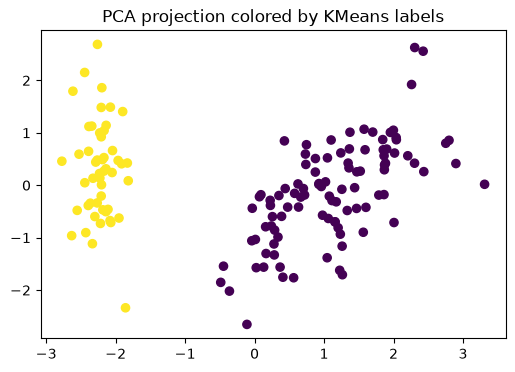

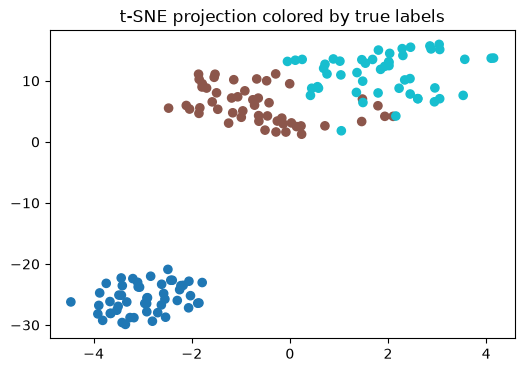

In [5]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(6, 4))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=km_labels, cmap="viridis", s=35)
plt.title("PCA projection colored by KMeans labels")
plt.show()

tsne = TSNE(n_components=2, random_state=42, learning_rate="auto", init="random", perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(6, 4))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_true, cmap="tab10", s=35)
plt.title("t-SNE projection colored by true labels")
plt.show()

## Section E - Customer Segmentation Simulation (Business View)

In [6]:
X_customer, _ = make_blobs(
    n_samples=600,
    centers=4,
    n_features=4,
    cluster_std=[0.8, 1.3, 0.9, 1.1],
    random_state=42,
)
X_customer = StandardScaler().fit_transform(X_customer)

km_customer = KMeans(n_clusters=4, random_state=42, n_init=20)
customer_labels = km_customer.fit_predict(X_customer)
print("customer silhouette:", round(silhouette_score(X_customer, customer_labels), 4))

customer silhouette: 0.8306


## Business Case Studies & Exceptions
- Segment usefulness must be validated with actionability, not silhouette alone.
- DBSCAN is useful when noise detection matters and cluster shapes are non-spherical.
- Exception: if operations mandate a fixed number of segments, business constraints can override metric-optimal k.

## Interview Questions & Answers
1. How does k-means work? Assignment to nearest centroid, then centroid recomputation iteratively.
2. How choose k? Combine silhouette/elbow, stability checks, and business constraints.